<a href="https://colab.research.google.com/github/rachitjha20/Lead_Scoring_Case_Study/blob/main/Lead_Scoring_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Importing Libraries

In [67]:
# basic libraries to work on the dataframe
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Importing libraries
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Ignoring Warnings
import warnings
warnings.filterwarnings('ignore')

#Increasing views limit of the columns
pd.options.display.max_columns = None
pd.options.display.max_rows = 150
pd.options.display.float_format = '{:.2f}'.format

## Data understanding and cleaning

### Data Understanding

In [68]:
df = pd.read_csv('Leads.csv') #
df.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Last Activity,Country,Specialization,How did you hear about X Education,What is your current occupation,What matters most to you in choosing a course,Search,Magazine,Newspaper Article,X Education Forums,Newspaper,Digital Advertisement,Through Recommendations,Receive More Updates About Our Courses,Tags,Lead Quality,Update me on Supply Chain Content,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.00,0,0.00,Page Visited on Website,NaN,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Interested in other courses,Low in Relevance,No,No,Select,Select,02.Medium,02.Medium,15.00,15.00,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.00,674,2.50,Email Opened,India,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,NaN,No,No,Select,Select,02.Medium,02.Medium,15.00,15.00,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.00,1532,2.00,Email Opened,India,Business Administration,Select,Student,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Potential Lead,Mumbai,02.Medium,01.High,14.00,20.00,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.00,305,1.00,Unreachable,India,Media and Advertising,Word Of Mouth,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Ringing,Not Sure,No,No,Select,Mumbai,02.Medium,01.High,13.00,17.00,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.00,1428,1.00,Converted to Lead,India,Select,Other,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Will revert after reading the email,Might be,No,No,Select,Mumbai,02.Medium,01.High,15.00,18.00,No,No,Modified


In [69]:
df.shape

(9240, 37)

In [70]:
df.describe()

,Lead Number,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Asymmetrique Activity Score,Asymmetrique Profile Score
count,9240.00,9240.00,9103.00,9240.00,9103.00,5022.00,5022.00
mean,617188.44,0.39,3.45,487.70,2.36,14.31,16.34
std,23406.00,0.49,4.85,548.02,2.16,1.39,1.81
min,579533.00,0.00,0.00,0.00,0.00,7.00,11.00
25%,596484.50,0.00,1.00,12.00,1.00,14.00,15.00
50%,615479.00,0.00,3.00,248.00,2.00,14.00,16.00
75%,637387.25,1.00,5.00,936.00,3.00,15.00,18.00
max,660737.00,1.00,251.00,2272.00,55.00,18.00,20.00


In [71]:
df.duplicated().sum()

0

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

#### Observations:

* A large number of null values are present in the columns. These columns should ideally be dropped.
* `Prospect ID` and `Lead Number` are columns that can be ignored, as both serve as unique identifiers. Hence, `Prospect ID` can be removed.
* Some column names contain spaces and are too long. We will be changing them.
* A few columns have `"Select"` as the option, which actually represents a null or NaN value. This occurs when the user doesn't choose anything and leaves the field as it is.

## Data Cleaning

#### Renaming Column Name

In [73]:
# Removing Space and Adding "_"
df.columns =df.columns.str.replace(" ", "_").str.lower()

df.columns

Index(['prospect_id', 'lead_number', 'lead_origin', 'lead_source',
       'do_not_email', 'do_not_call', 'converted', 'totalvisits',
       'total_time_spent_on_website', 'page_views_per_visit', 'last_activity',
       'country', 'specialization', 'how_did_you_hear_about_x_education',
       'what_is_your_current_occupation',
       'what_matters_most_to_you_in_choosing_a_course', 'search', 'magazine',
       'newspaper_article', 'x_education_forums', 'newspaper',
       'digital_advertisement', 'through_recommendations',
       'receive_more_updates_about_our_courses', 'tags', 'lead_quality',
       'update_me_on_supply_chain_content', 'get_updates_on_dm_content',
       'lead_profile', 'city', 'asymmetrique_activity_index',
       'asymmetrique_profile_index', 'asymmetrique_activity_score',
       'asymmetrique_profile_score',
       'i_agree_to_pay_the_amount_through_cheque',
       'a_free_copy_of_mastering_the_interview', 'last_notable_activity'],
      dtype='object')

In [74]:
# Shortern column name length

df.rename(columns = {'totalvisits': 'total_visits', 'total_time_spent_on_website': 'time_on_website',
                    'how_did_you_hear_about_x_education': 'source', 'what_is_your_current_occupation': 'occupation',
                    'what_matters_most_to_you_in_choosing_a_course' : 'course_selection_reason',
                    'receive_more_updates_about_our_courses': 'courses_updates',
                     'update_me_on_supply_chain_content': 'supply_chain_content_updates',
                    'get_updates_on_dm_content': 'dm_content_updates',
                    'i_agree_to_pay_the_amount_through_cheque': 'cheque_payment',
                    'a_free_copy_of_mastering_the_interview': 'mastering_interview'}, inplace = True)

df.head(1)

,prospect_id,lead_number,lead_origin,lead_source,do_not_email,do_not_call,converted,total_visits,time_on_website,page_views_per_visit,last_activity,country,specialization,source,occupation,course_selection_reason,search,magazine,newspaper_article,x_education_forums,newspaper,digital_advertisement,through_recommendations,courses_updates,tags,lead_quality,supply_chain_content_updates,dm_content_updates,lead_profile,city,asymmetrique_activity_index,asymmetrique_profile_index,asymmetrique_activity_score,asymmetrique_profile_score,cheque_payment,mastering_interview,last_notable_activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.00,0,0.00,Page Visited on Website,NaN,Select,Select,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,Interested in other courses,Low in Relevance,No,No,Select,Select,02.Medium,02.Medium,15.00,15.00,No,No,Modified


#### Droping prospect_id Column

In [75]:
df.drop('prospect_id', axis=1, inplace = True)

#### Replacing the "Select" With Null Values


In [76]:
df_obj = df.select_dtypes(include= 'object')

# Finding columns which have "Select"

s = lambda x: x.str.contains('Select', na = False)
# Making list of columns label which have "Select"
l = df_obj.columns[df_obj.apply(s).any()].tolist()
print(l)

['specialization', 'source', 'lead_profile', 'city']


In [77]:
sel_obj = ['specialization', 'source', 'lead_profile', 'city']
df[sel_obj] = df[sel_obj].replace('Select', np.NaN)

#### Handeling the null Values

* Since several columns have a significant number of null entries, let's first calculate the percentage of null values in each column and then make a decision based on the results.
* Additionally, we can drop the sales-generated columns, as they contain data recorded after the sales team has contacted the student. This data is not relevant to the purpose of our model, which is to provide a lead score. The columns to be dropped are:

  - `tags`
  - `lead_quality`
  - `All asymmetrique columns`
  - `last_activity`
  - `last_notable_activity`

In [78]:
df.isnull().mean()*100

,0
lead_number,0.00
lead_origin,0.00
lead_source,0.39
do_not_email,0.00
do_not_call,0.00
converted,0.00
total_visits,1.48
time_on_website,0.00
page_views_per_visit,1.48
last_activity,1.11


##### Observation
- As we can see that there are multiple columns with missing data. Since there are no ways to get the data back from reliable source, so we will be dropping all the columns which have Null value percentage equal or above 40%

#### Droping Columns with Null Value >= 40%

In [79]:
for column in df.columns:
  if df[column].isnull().mean()*100 >= 40:
    df.drop(column, axis = 1, inplace = True)
    print(f"!!! Dropped {column}")

!!! Dropped source
!!! Dropped lead_quality
!!! Dropped lead_profile
!!! Dropped asymmetrique_activity_index
!!! Dropped asymmetrique_profile_index
!!! Dropped asymmetrique_activity_score
!!! Dropped asymmetrique_profile_score


In [80]:
x = ['tags', 'last_activity', 'last_notable_activity']
df.drop(x, axis=1, inplace=True)
print(f"!!! Dropped columns: {x}")

!!! Dropped columns: ['tags', 'last_activity', 'last_notable_activity']


In [81]:
# Let's look at what are we left with
# Calculatuing null percentage
df.isnull().mean()*100

,0
lead_number,0.00
lead_origin,0.00
lead_source,0.39
do_not_email,0.00
do_not_call,0.00
converted,0.00
total_visits,1.48
time_on_website,0.00
page_views_per_visit,1.48
country,26.63


In [82]:
df.head(20)

,lead_number,lead_origin,lead_source,do_not_email,do_not_call,converted,total_visits,time_on_website,page_views_per_visit,country,specialization,occupation,course_selection_reason,search,magazine,newspaper_article,x_education_forums,newspaper,digital_advertisement,through_recommendations,courses_updates,supply_chain_content_updates,dm_content_updates,city,cheque_payment,mastering_interview
0,660737,API,Olark Chat,No,No,0,0.00,0,0.00,NaN,NaN,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,No,No,NaN,No,No
1,660728,API,Organic Search,No,No,0,5.00,674,2.50,India,NaN,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,No,No,NaN,No,No
2,660727,Landing Page Submission,Direct Traffic,No,No,1,2.00,1532,2.00,India,Business Administration,Student,Better Career Prospects,No,No,No,No,No,No,No,No,No,No,Mumbai,No,Yes
3,660719,Landing Page Submission,Direct Traffic,No,No,0,1.00,305,1.00,India,Media and Advertising,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,No,No,Mumbai,No,No
4,660681,Landing Page Submission,Google,No,No,1,2.00,1428,1.00,India,NaN,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,No,No,Mumbai,No,No
5,660680,API,Olark Chat,No,No,0,0.00,0,0.00,NaN,NaN,NaN,NaN,No,No,No,No,No,No,No,No,No,No,NaN,No,No
6,660673,Landing Page Submission,Google,No,No,1,2.00,1640,2.00,India,Supply Chain Management,Unemployed,Better Career Prospects,No,No,No,No,No,No,No,No,No,No,Mumbai,No,No
7,660664,API,Olark Chat,No,No,0,0.00,0,0.00,NaN,NaN,NaN,NaN,No,No,No,No,No,No,No,No,No,No,NaN,No,No
8,660624,Landing Page Submission,Direct Traffic,No,No,0,2.00,71,2.00,India,IT Projects Management,NaN,NaN,No,No,No,No,No,No,No,No,No,No,Thane & Outskirts,No,Yes
9,660616,API,Google,No,No,0,4.00,58,4.00,India,Finance Management,NaN,NaN,No,No,No,No,No,No,No,No,No,No,Mumbai,No,No


##### Observation
- Five columns have high null values: `country, specialization, occupation, course_selection_reason, and city`. Analyze each column to determine the best imputation method

#### Country Column

In [83]:
df.country.value_counts(normalize=True, dropna = False)* 100

,proportion
country,
India,70.26
NaN,26.63
United States,0.75
United Arab Emirates,0.57
Singapore,0.26
Saudi Arabia,0.23
United Kingdom,0.16
Australia,0.14
Qatar,0.11


##### Observation

- 97% of data is from India (including nulls).

- Consider dropping "Country" column due to high skewness and null values. If needed, we will use city column for more granular analysis.

In [84]:
df.drop(['country'], axis=1, inplace = True)

#### City Column

In [85]:
df.city.value_counts(normalize=True, dropna = False)* 100

,proportion
city,
NaN,39.71
Mumbai,34.87
Thane & Outskirts,8.14
Other Cities,7.42
Other Cities of Maharashtra,4.95
Other Metro Cities,4.11
Tier II Cities,0.80


##### Observation

- We will categorize cities based on logical decisions and impute proportionately

In [86]:
# Categorizing Cities
# 1) All Non-Mumbai but Maharasthran Cities

df.loc[(df.city == 'Thane & Outskirts') | (df.city == 'Other Cities of Maharashtra'), 'city'] = 'Non_Mumbai_Maharasthran_Cities'

# 2) All other cities
df.loc[(df.city == 'Other Cities') | (df.city == 'Other Metro Cities') | (df.city == 'Tier II Cities') ,
       'city'] = 'Non_Maharashtra_Cities'

In [87]:
# Checking new values

df.city.value_counts(normalize=True)* 100

,proportion
city,
Mumbai,57.84
Non_Mumbai_Maharasthran_Cities,21.70
Non_Maharashtra_Cities,20.46


In [88]:
df['city'] = df.city.fillna(pd.Series(np.random.choice(
    ['Mumbai','Non_Mumbai_Maharasthran_Cities', 'Non_Maharashtra_Cities'],
    p = [0.5784, 0.2170, 0.2046], size=len(df))))

#### Occupation Column


In [89]:
df.occupation.value_counts(normalize = True, dropna = False) * 100


,proportion
occupation,
Unemployed,60.61
NaN,29.11
Working Professional,7.64
Student,2.27
Other,0.17
Housewife,0.11
Businessman,0.09


##### Observation

 - For this we can firt combine the data ap per our understanding and then impute propotionally to maintain the distribution.

In [90]:
# Joining low representing categories
df.loc[(df.occupation == 'Student') | (df.occupation == 'Other') | (df.occupation == 'Housewife') |
       (df.occupation == 'Businessman') , 'occupation'] = 'Student and Others'

df.occupation.value_counts(normalize = True) * 100


,proportion
occupation,
Unemployed,85.50
Working Professional,10.78
Student and Others,3.73


In [91]:
# imputing the data proportionately

df['occupation'] = df.occupation.fillna(pd.Series(np.random.choice(
    ['Unemployed', 'Working Professional','Student and Others'],
    p = [0.8550, 0.1078, 0.0372], size = len(df))))

df.occupation.value_counts(normalize = True) * 100


,proportion
occupation,
Unemployed,85.38
Working Professional,10.94
Student and Others,3.68


#### course_selection_reason Column

In [92]:
df.course_selection_reason.value_counts(normalize = True, dropna = False) * 100

,proportion
course_selection_reason,
Better Career Prospects,70.65
NaN,29.32
Flexibility & Convenience,0.02
Other,0.01


##### Observation

- The distribution of the data is very heavily skewed, with Better career prospects + null values = approx 100% of the total. It is safe to drop this column.

In [93]:
df.drop('course_selection_reason', axis = 1, inplace = True)

#### Specialization Column

In [94]:
df.specialization.value_counts(normalize = True, dropna = False) * 100

,proportion
specialization,
NaN,36.58
Finance Management,10.56
Human Resource Management,9.18
Marketing Management,9.07
Operations Management,5.44
Business Administration,4.36
IT Projects Management,3.96
Supply Chain Management,3.78
"Banking, Investment And Insurance",3.66


##### Observation

- For this we can firts combine data on field type basis and then impute proportionally to maintain the ratio without any bias.

In [95]:
# Categorization of data below
#  all management courses
df.loc[(df.specialization == 'Finance Management') | (df.specialization == 'Human Resource Management') |
       (df.specialization == 'Marketing Management') |  (df.specialization == 'Operations Management') |
       (df.specialization == 'IT Projects Management') | (df.specialization == 'Supply Chain Management') |
       (df.specialization == 'Healthcare Management') | (df.specialization == 'Hospitality Management') |
       (df.specialization == 'Retail Management') , 'specialization'] = 'Management Specializations'

#  all busines courses
df.loc[(df.specialization == 'Business Administration') | (df.specialization == 'International Business') |
       (df.specialization == 'Rural and Agribusiness') | (df.specialization == 'E-Business')
        , 'specialization'] = 'Business Specializations'

#  all industry courses
df.loc[(df.specialization == 'Banking, Investment And Insurance') | (df.specialization == 'Media and Advertising') |
       (df.specialization == 'Travel and Tourism') | (df.specialization == 'Services Excellence') |
       (df.specialization == 'E-COMMERCE'), 'specialization'] = 'Industry Specializations'


df.specialization.value_counts(normalize = True, dropna = False) * 100

,proportion
specialization,
Management Specializations,46.03
NaN,36.58
Industry Specializations,9.70
Business Specializations,7.69


In [96]:
# Imputing proportionally

df['specialization'] = df.specialization.fillna(pd.Series(np.random.choice(
    ['Management Specializations', 'Business Specializations', 'Industry Specializations'],
    p = [0.7258, 0.1213, 0.1529 ], size = len(df))))

df.specialization.value_counts(normalize = True, dropna = False) * 100

,proportion
specialization,
Management Specializations,72.81
Industry Specializations,14.91
Business Specializations,12.27


#### Handling categorical column

In this step, we will go through the rest of the categorical columns one by one and

- Merge categories that have low representation
- Impute the missing values

In [97]:
(df.isnull().mean())* 100

,0
lead_number,0.00
lead_origin,0.00
lead_source,0.39
do_not_email,0.00
do_not_call,0.00
converted,0.00
total_visits,1.48
time_on_website,0.00
page_views_per_visit,1.48
specialization,0.00


In [98]:
for k, v in df.select_dtypes(include='object').nunique().to_dict().items():
  print('{} = {}, dtype: {}'.format(k, v, df[k].dtype))


lead_origin = 5, dtype: object
lead_source = 21, dtype: object
do_not_email = 2, dtype: object
do_not_call = 2, dtype: object
specialization = 3, dtype: object
occupation = 3, dtype: object
search = 2, dtype: object
magazine = 1, dtype: object
newspaper_article = 2, dtype: object
x_education_forums = 2, dtype: object
newspaper = 2, dtype: object
digital_advertisement = 2, dtype: object
through_recommendations = 2, dtype: object
courses_updates = 1, dtype: object
supply_chain_content_updates = 1, dtype: object
dm_content_updates = 1, dtype: object
city = 3, dtype: object
cheque_payment = 1, dtype: object
mastering_interview = 2, dtype: object


##### Observation

- As can be seen from the above output, the categorical columns (i.e. number of unique values > 2) are:

  - `lead_origin`
  - `lead_source`

#### lead_origin Column


In [99]:
df.lead_origin.value_counts(normalize= True, dropna = False) * 100

,proportion
lead_origin,
Landing Page Submission,52.88
API,38.74
Lead Add Form,7.77
Lead Import,0.60
Quick Add Form,0.01


In [100]:
# Lets group together the smaller value as multiples are present

df.loc[(df.lead_origin == 'Lead Import') | (df.lead_origin == 'Quick Add Form')
| (df.lead_origin == 'Lead Add Form'), 'lead_origin'] = 'Lead Add Form and Others'

# Printing the new distribution
df.lead_origin.value_counts(normalize = True) * 100

,proportion
lead_origin,
Landing Page Submission,52.88
API,38.74
Lead Add Form and Others,8.38


#### lead_source Column

In [101]:
df.lead_source.value_counts(normalize= True, dropna = False) * 100

,proportion
lead_source,
Google,31.04
Direct Traffic,27.52
Olark Chat,18.99
Organic Search,12.49
Reference,5.78
Welingak Website,1.54
Referral Sites,1.35
Facebook,0.60
NaN,0.39


In [102]:
# Lets impute the missing values with the mode of data i.e. clearly 'Google'
df.lead_source.fillna(df.lead_source.mode()[0], inplace=True)

In [103]:
#There are a lot of smaller values which will not be used as definitive factors, lets group them together
df['lead_source'] = df['lead_source'].apply(lambda x: x if
                                            ((x== 'Google') | (x=='Direct Traffic') | (x=='Olark Chat') |
                                             (x=='Organic Search') | (x=='Reference'))
                                            else 'Other Social Sites')

In [104]:
df.lead_source.value_counts(normalize= True) * 100

,proportion
lead_source,
Google,31.43
Direct Traffic,27.52
Olark Chat,18.99
Organic Search,12.49
Reference,5.78
Other Social Sites,3.79


#### Handling Binary Column

- Drop those columns that have significant data imbalance
- Drop all those columns that have only 1 unique entry

In [105]:
# determine unique values
for k, v in df.select_dtypes(include='object').nunique().to_dict().items():
    print('{} = {}'.format(k,v))

lead_origin = 3
lead_source = 6
do_not_email = 2
do_not_call = 2
specialization = 3
occupation = 3
search = 2
magazine = 1
newspaper_article = 2
x_education_forums = 2
newspaper = 2
digital_advertisement = 2
through_recommendations = 2
courses_updates = 1
supply_chain_content_updates = 1
dm_content_updates = 1
city = 3
cheque_payment = 1
mastering_interview = 2


##### Observation

- The following columns can be dropped as they have just 1 unique values
  - magazine
  - course_updates
  - supply_chain_content_updates
  - dm_content_updates
  - cheque_payment
-Let's now check the data imbalance for the rest of the columns

In [106]:
# select rest of the binary columns in a new dataframe
df_bin = df[['do_not_email', 'do_not_call', 'search', 'newspaper_article', 'x_education_forums',
           'newspaper', 'digital_advertisement', 'through_recommendations', 'mastering_interview']]

# see value counts for each of the columns
for i in df_bin.columns:
    x = (df_bin[i].value_counts(normalize = True)) * 100
    print(x)
    print()

do_not_email
No    92.06
Yes    7.94
Name: proportion, dtype: float64

do_not_call
No    99.98
Yes    0.02
Name: proportion, dtype: float64

search
No    99.85
Yes    0.15
Name: proportion, dtype: float64

newspaper_article
No    99.98
Yes    0.02
Name: proportion, dtype: float64

x_education_forums
No    99.99
Yes    0.01
Name: proportion, dtype: float64

newspaper
No    99.99
Yes    0.01
Name: proportion, dtype: float64

digital_advertisement
No    99.96
Yes    0.04
Name: proportion, dtype: float64

through_recommendations
No    99.92
Yes    0.08
Name: proportion, dtype: float64

mastering_interview
No    68.74
Yes   31.26
Name: proportion, dtype: float64



##### Observations
- Because of heavy data imbalance, we can drop the following columns as well
  * `do_not_call`
  * `search`
  * `newspaper_article`
  * `x_education_forums`
  * `newspaper`
  * `digital_advertisement`
  * `through_recommendations`

In [107]:
drop_bin = ['do_not_call', 'search', 'newspaper_article', 'x_education_forums',
           'newspaper', 'digital_advertisement', 'through_recommendations', 'magazine', 'courses_updates',
           'supply_chain_content_updates', 'dm_content_updates', 'cheque_payment']

df.drop(drop_bin, axis = 1, inplace = True)

#### Handling Numerical Columns



- lead_number column is a unique identifier for each leads. Therefore, aggregations won't be of any relevance. We should change it to object

In [108]:
df.lead_number = df.lead_number.astype('object')

#### total_visits column

- Need to handle the missing values
- Convert all the data in integer form as visit can't be in float.

In [109]:
df.total_visits.fillna(df.total_visits.median(), inplace=True)
df.total_visits = df.total_visits.astype('int')


#### page_vies_per_visit Column

- Need to handle the missing values

In [110]:
df.page_views_per_visit.fillna(df.page_views_per_visit.median(), inplace=True)

In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   lead_number           9240 non-null   object 
 1   lead_origin           9240 non-null   object 
 2   lead_source           9240 non-null   object 
 3   do_not_email          9240 non-null   object 
 4   converted             9240 non-null   int64  
 5   total_visits          9240 non-null   int64  
 6   time_on_website       9240 non-null   int64  
 7   page_views_per_visit  9240 non-null   float64
 8   specialization        9240 non-null   object 
 9   occupation            9240 non-null   object 
 10  city                  9240 non-null   object 
 11  mastering_interview   9240 non-null   object 
dtypes: float64(1), int64(3), object(8)
memory usage: 866.4+ KB


## Exploratory Data Analysis

### Numerical Columns

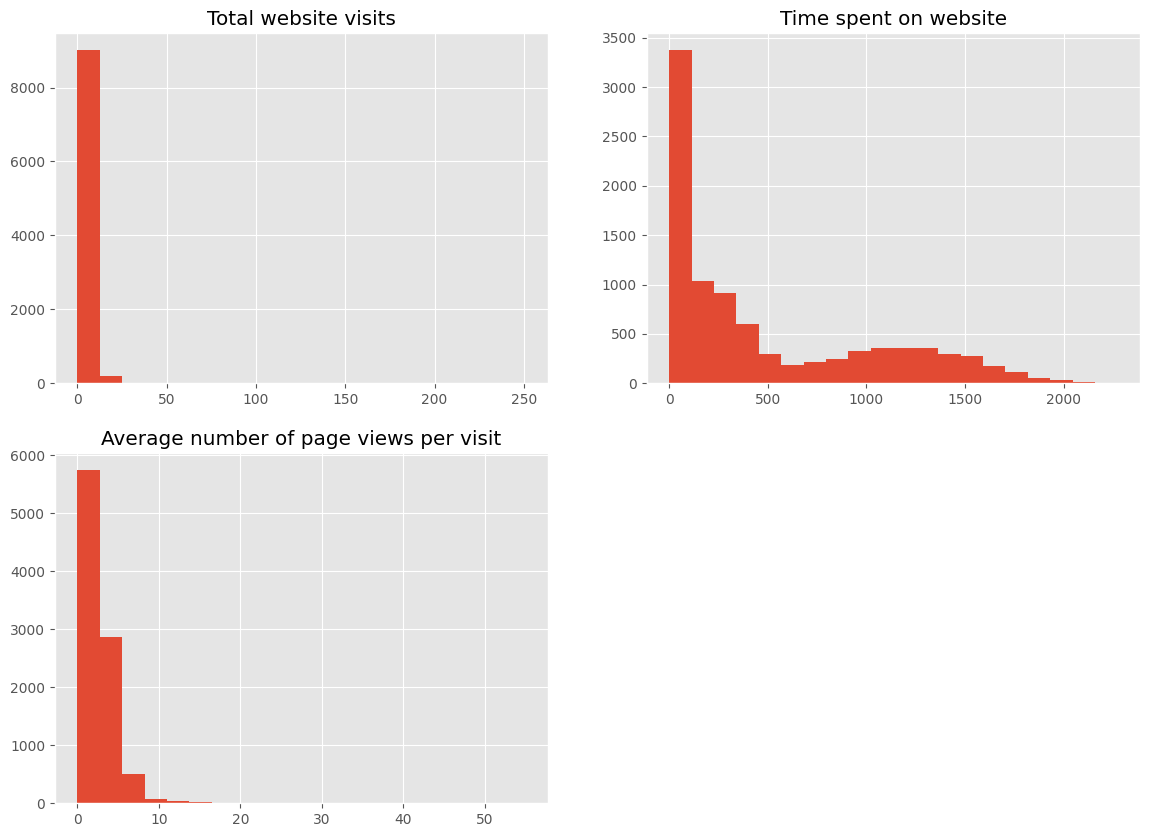

In [112]:
# Set style
plt.style.use('ggplot')

# See distribution of each of these columns
fig = plt.figure(figsize = (14, 10))
plt.subplot(2, 2, 1)
plt.hist(df.total_visits, bins = 20)
plt.title('Total website visits')

plt.subplot(2, 2, 2)
plt.hist(df.time_on_website, bins = 20)
plt.title('Time spent on website')

plt.subplot(2, 2, 3)
plt.hist(df.page_views_per_visit, bins = 20)
plt.title('Average number of page views per visit')

plt.show()

Observations
- High peaks and skewed data. There might be a possibility of outliers. We will check them next

Heatmap

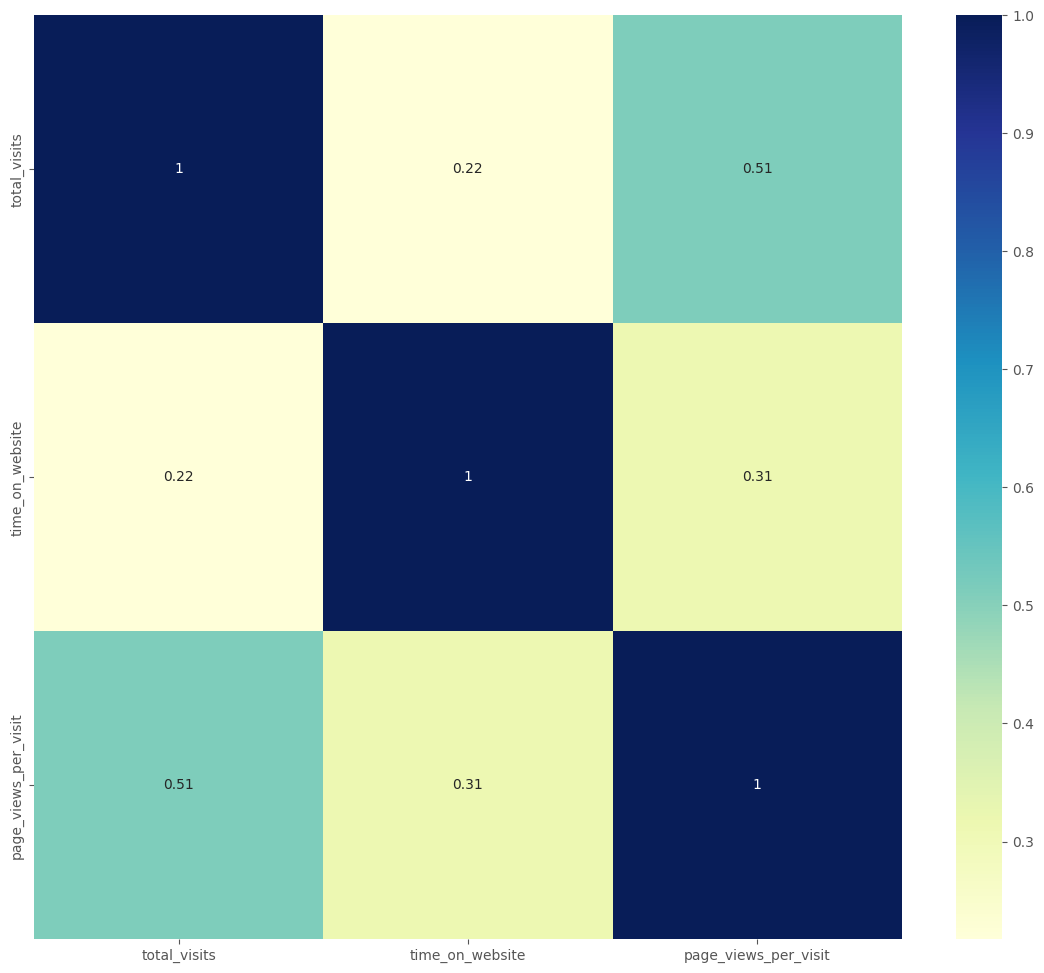

In [113]:
plt.figure(figsize = (14,12))
sns.heatmap(df[['total_visits', 'time_on_website', 'page_views_per_visit']].corr(), cmap="YlGnBu", annot = True)
plt.show()

Observations

- No significaqnt correlation such that columns can be dropped

Checking for outliers

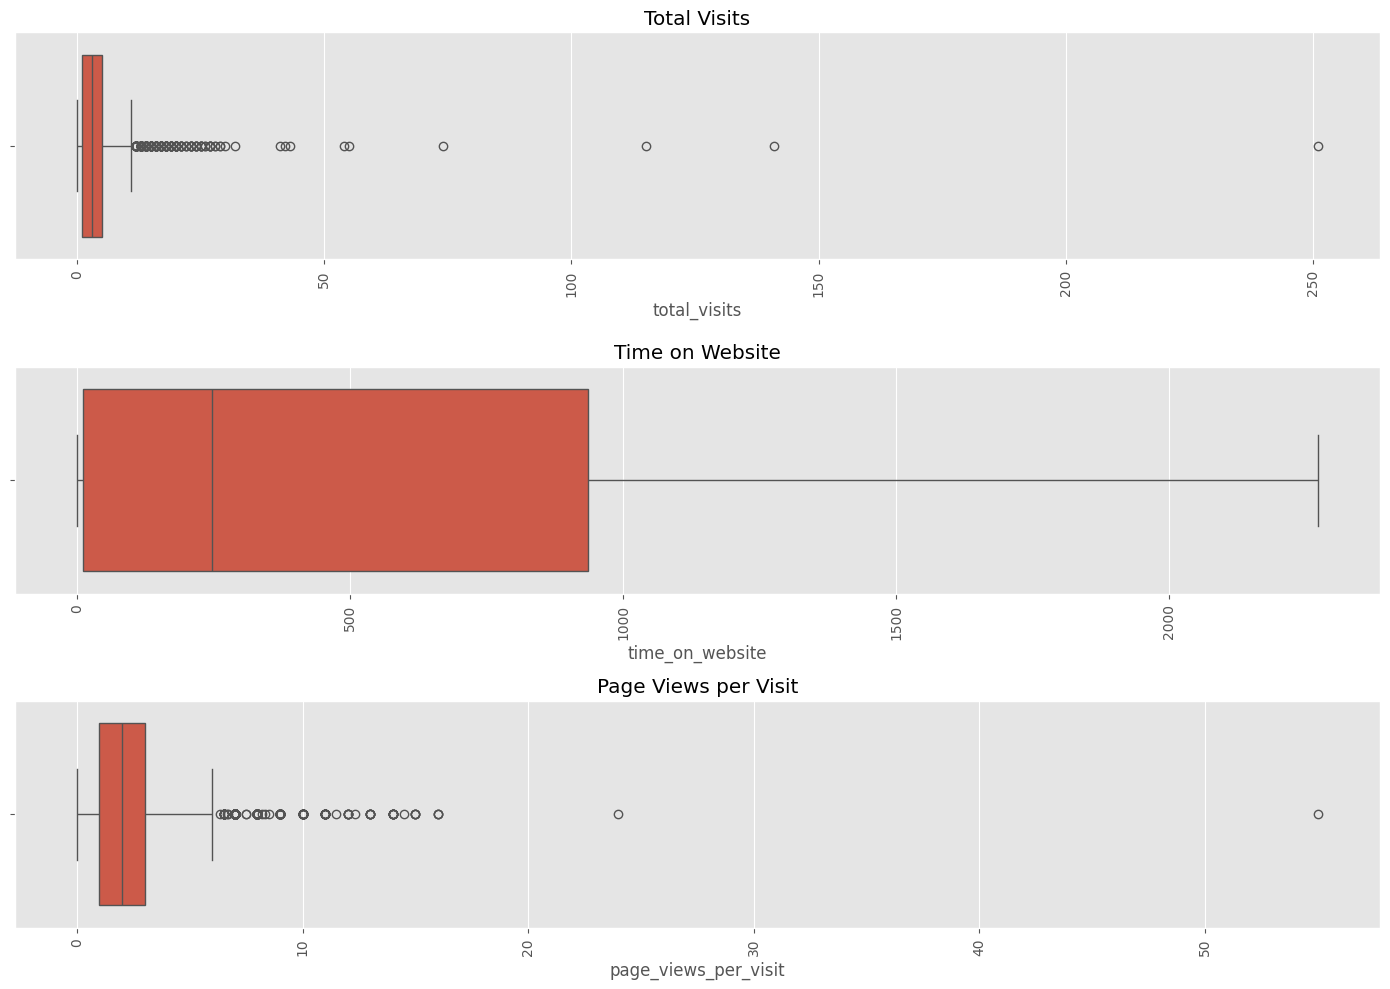

In [116]:
plt.figure(figsize=(14, 10))

# First subplot (rotated by 90 degrees)
plt.subplot(3, 1, 1)
sns.boxplot(x=df.total_visits)
plt.title("Total Visits")
plt.xticks(rotation=90)

# Second subplot (rotated by 90 degrees)
plt.subplot(3, 1, 2)
sns.boxplot(x=df.time_on_website)
plt.title("Time on Website")
plt.xticks(rotation=90)

# Third subplot (rotated by 90 degrees)
plt.subplot(3, 1, 3)
sns.boxplot(x=df.page_views_per_visit)
plt.title("Page Views per Visit")
plt.xticks(rotation=90)

plt.tight_layout()  # Adjust spacing between subplots
plt.show()


Observations

- Looking at both the box plots and the statistics, there are upper bound outliers in both total_visits and page_views_per_visit columns. We can also see that the data can be capped at 99 percentile.

### Categorical Columns

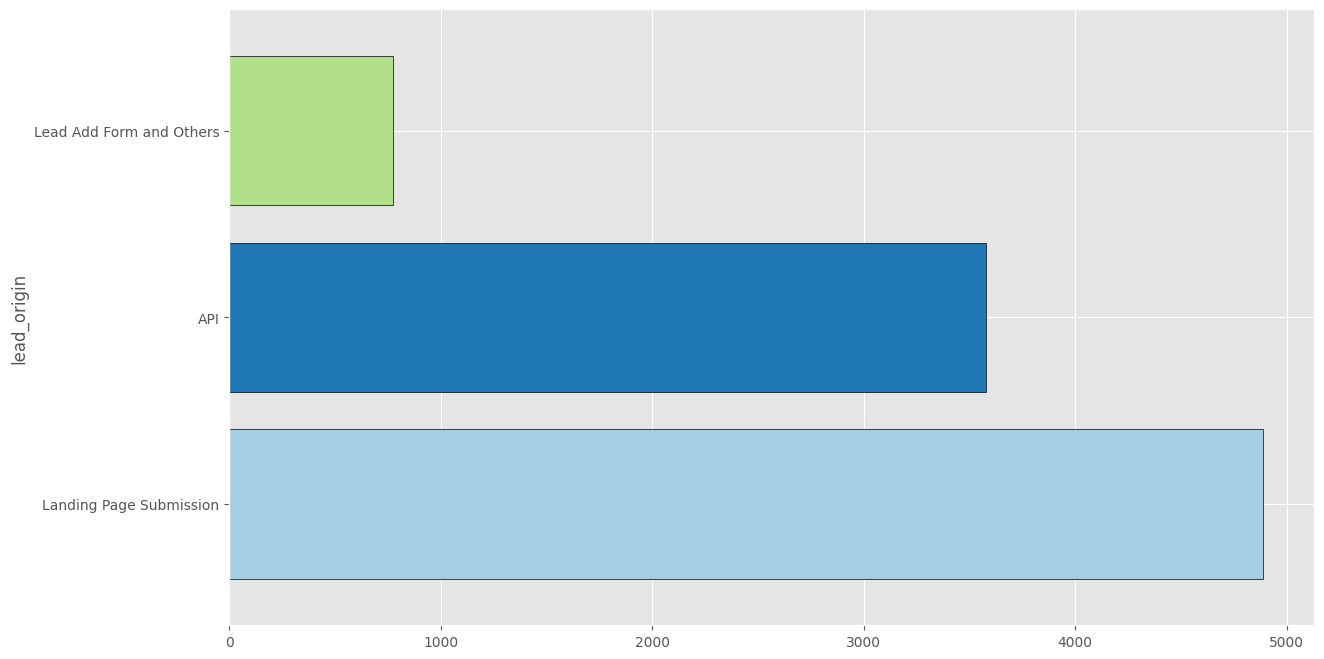

In [117]:
plt.figure(figsize = (14, 8))

df.groupby('lead_origin')['lead_number'].count().sort_values(ascending = False).plot(kind= 'barh', width = 0.8,
                                                            edgecolor = 'black',
                                                            color = plt.cm.Paired(np.arange(len(df))))
plt.show()

In [118]:
df.head(1)

,lead_number,lead_origin,lead_source,do_not_email,converted,total_visits,time_on_website,page_views_per_visit,specialization,occupation,city,mastering_interview
0,660737,API,Olark Chat,No,0,0,0,0.00,Management Specializations,Unemployed,Mumbai,No


Lead Source

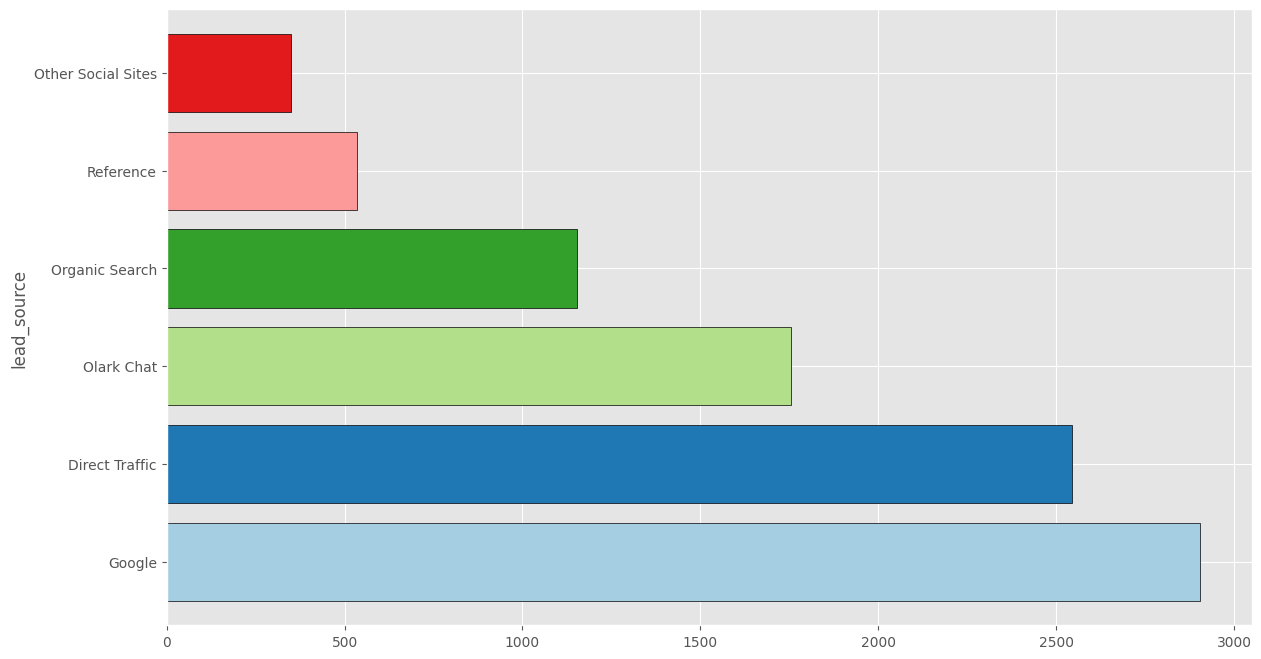

In [119]:
plt.figure(figsize = (14, 8))

df.groupby('lead_source')['lead_number'].count().sort_values(ascending = False).plot(kind= 'barh', width = 0.8,
                                                            edgecolor = 'black',
                                                            color = plt.cm.Paired(np.arange(len(df))))
plt.show()

Specialization

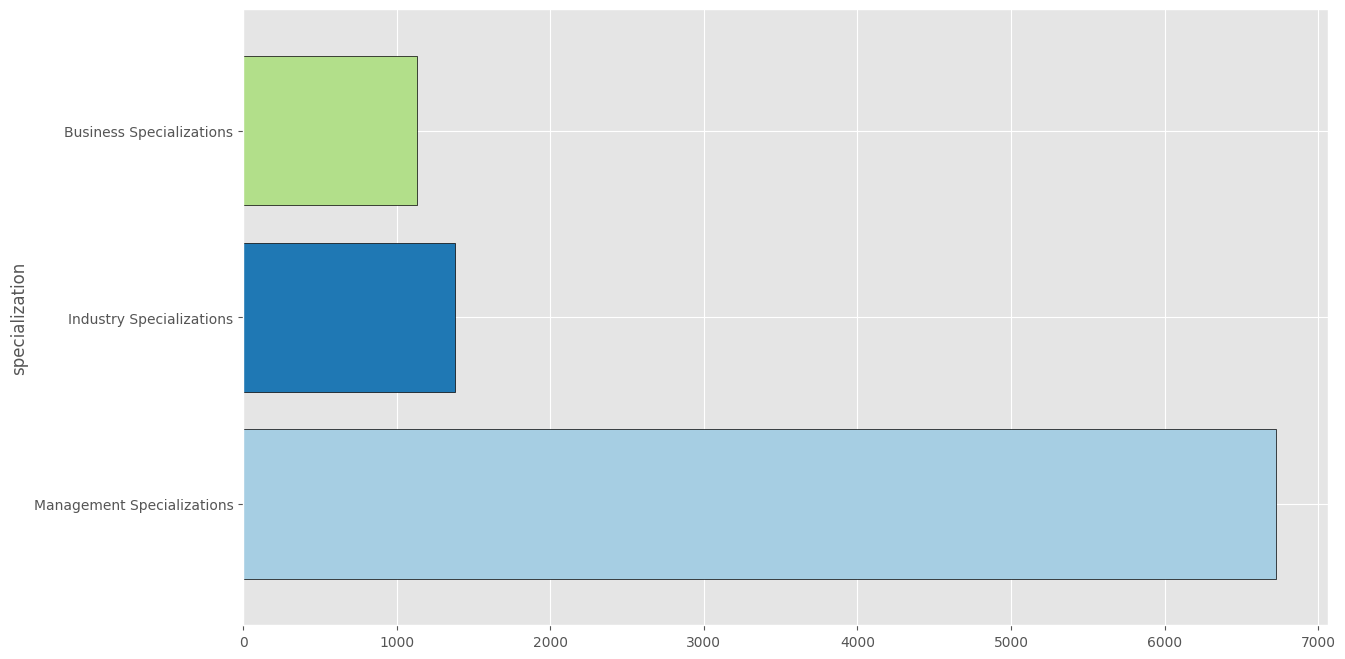

In [120]:
plt.figure(figsize = (14, 8))

df.groupby('specialization')['lead_number'].count().sort_values(ascending = False).plot(kind= 'barh', width = 0.8,
                                                            edgecolor = 'black',
                                                            color = plt.cm.Paired(np.arange(len(df))))
plt.show()

Observation
- Most of the speciliazation taken are management

Occupation

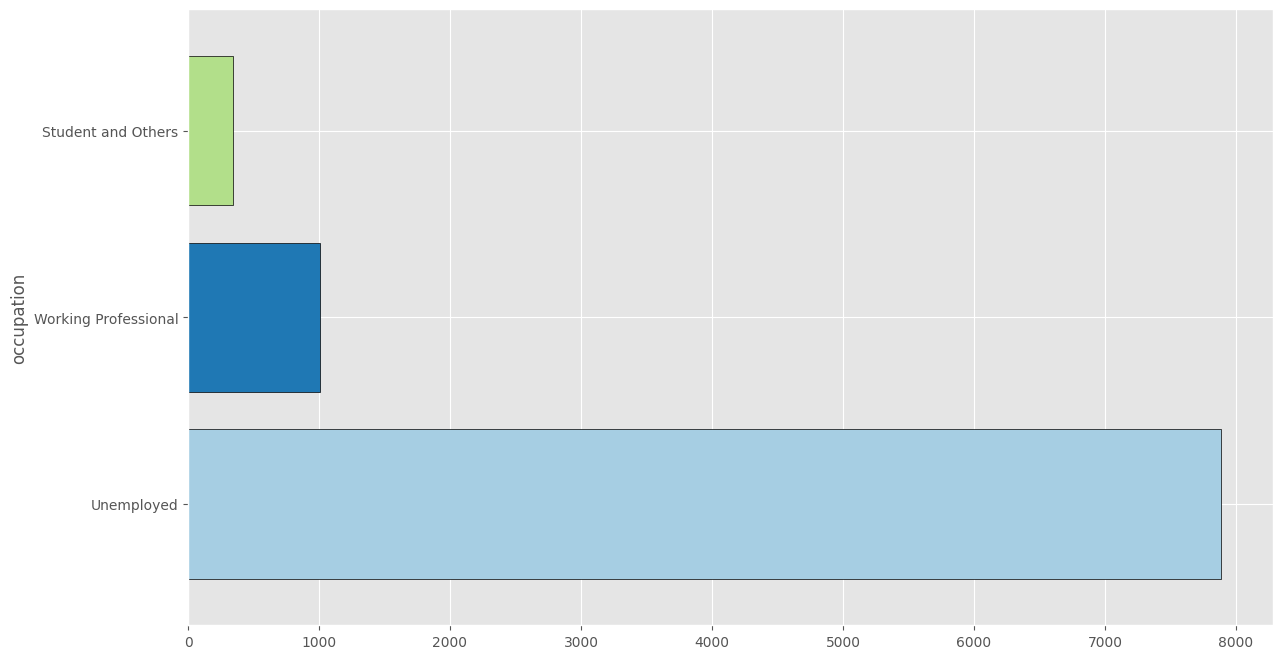

In [121]:
plt.figure(figsize = (14, 8))

df.groupby('occupation')['lead_number'].count().sort_values(ascending = False).plot(kind= 'barh', width = 0.8,
                                                            edgecolor = 'black',
                                                            color = plt.cm.Paired(np.arange(len(df))))
plt.show()

Observation
- Unempployed users are the most significant leads

City

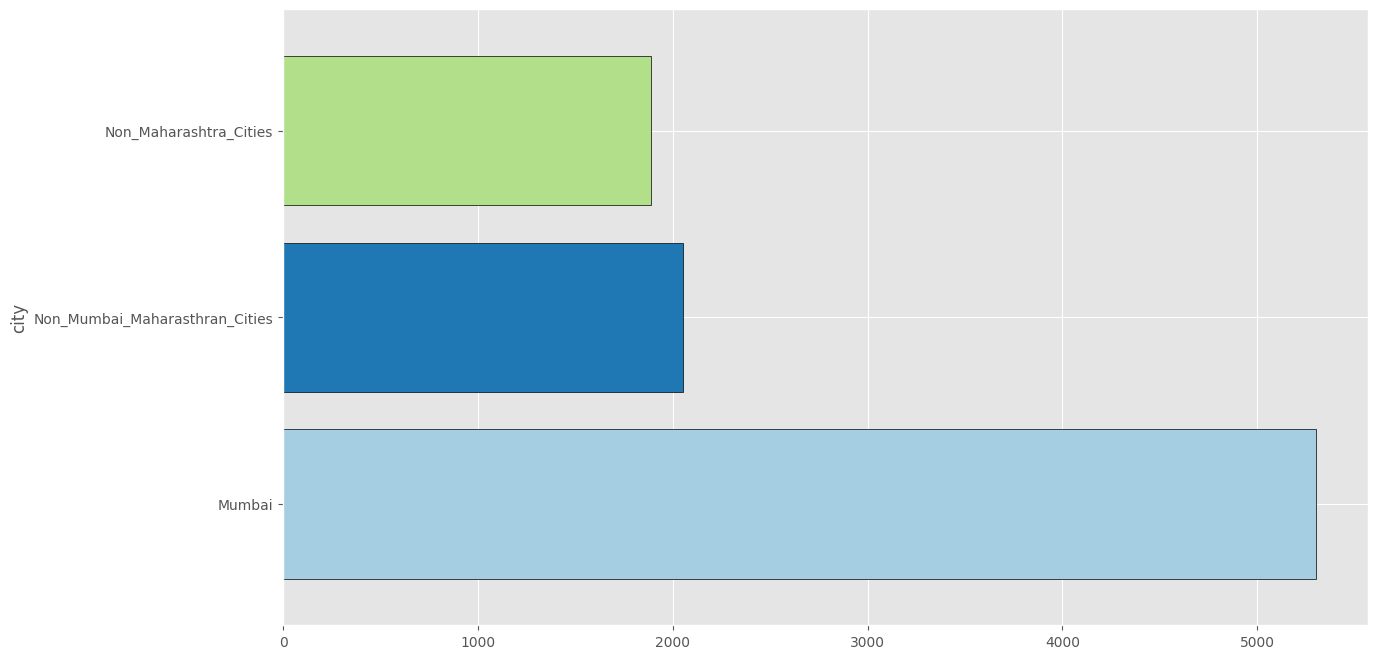

In [122]:
plt.figure(figsize = (14, 8))

df.groupby('city')['lead_number'].count().sort_values(ascending = False).plot(kind= 'barh', width = 0.8,
                                                            edgecolor = 'black',
                                                            color = plt.cm.Paired(np.arange(len(df))))
plt.show()

Observation

- Mumbai in particular and Maharashtra in general dominates the lead. This is likely due to the fact that the courses are based in Mumbai

Do Not Email

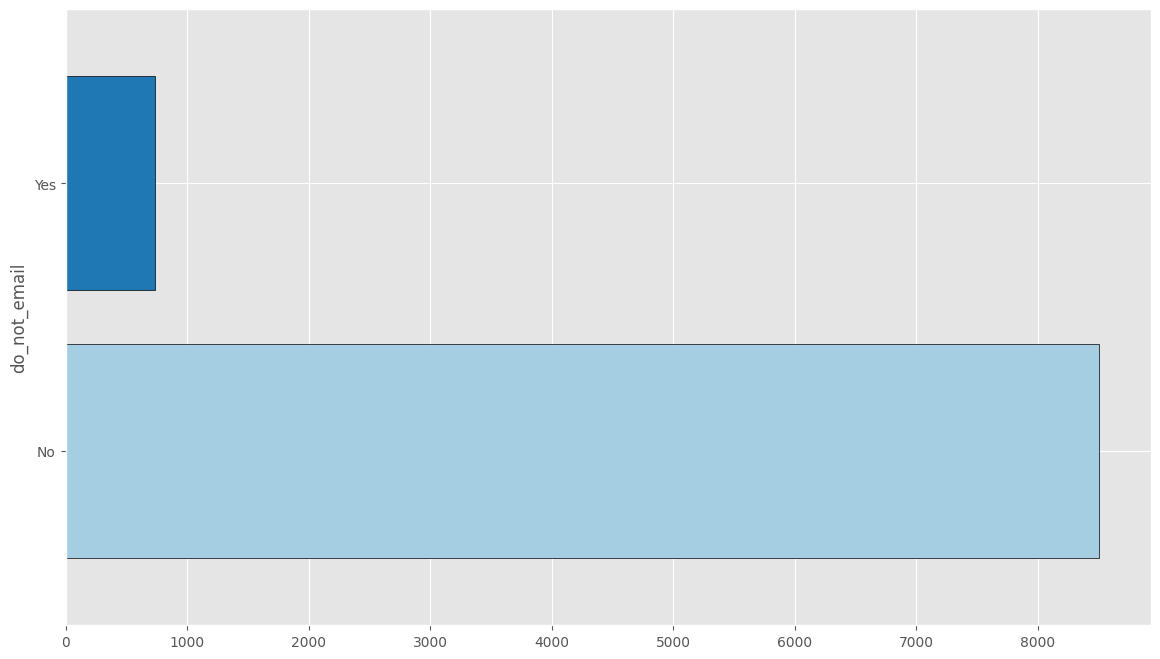

In [124]:
plt.figure(figsize = (14, 8))

df.groupby('do_not_email')['lead_number'].count().sort_values(ascending = False).plot(kind= 'barh', width = 0.8,
                                                            edgecolor = 'black',
                                                            color = plt.cm.Paired(np.arange(len(df))))
plt.show()